##  **Ordinal Logistic Regression**

### **Project :** 
    - Customer Satisfaction Level Prediction

### **Problem Statement :**
    - Predict customer satisfaction levels such as low, medium, or high


In [1]:
!pip install mord


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sagar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import mord

In [3]:


# Step No 1 : Importing Required Libraries 

# Numerical operations 
import numpy as np 

# Data manipulation and analysis 
import pandas as pd 

# Data Visualization 
import matplotlib.pyplot as plt 

# Advanced Data Visualization
import seaborn as sns 

# Machine Learning algorithms and tools

# Splitting the dataset into training and testing sets 
from sklearn.model_selection import train_test_split

# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix 

# Ordinal Logistic Regression
from mord import LogisticAT

In [4]:
# Step 2 : Loading the Dataset 
df = pd.read_csv("customer_satisfaction_dataset.csv")

In [5]:
# Step No 3 : Understanding the Dataset 

# Display first rows 
print(df.head())

# Display dataset shape
print(df.shape)

# Display dataset info 
print(df.info())

# Display summary statistics 
print(df.describe())



   CustomerID  Age  MonthlyIncome  PurchaseFrequency  SupportRating  \
0           1   22          25000                  2              2   
1           2   25          28000                  3              3   
2           3   27          30000                  4              3   
3           4   29          32000                  4              4   
4           5   31          35000                  5              4   

  SatisfactionLevel  
0               Low  
1               Low  
2               Low  
3            Medium  
4            Medium  
(30, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         30 non-null     int64 
 1   Age                30 non-null     int64 
 2   MonthlyIncome      30 non-null     int64 
 3   PurchaseFrequency  30 non-null     int64 
 4   SupportRating      30 non-null     int64 
 5

In [6]:
# Step No 4 : Data Preprocessing and Data Cleaning 

# Check for missing values 
print(df.isnull().sum())

# Check for duplicates 
print(df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

CustomerID           0
Age                  0
MonthlyIncome        0
PurchaseFrequency    0
SupportRating        0
SatisfactionLevel    0
dtype: int64
0


In [7]:
# Step No 5 : Encode Target Variable 

# Crate label encoder object 
encoder = LabelEncoder()

# Convert satisfaction Levels into numerical values 
df["SatisfactionLevel"] = encoder.fit_transform(df["SatisfactionLevel"])

# Low = 0
# Medium = 1 
# High = 2

In [8]:
# Step No 6 : Features and Target Splitting 

# Define input feautures 
X = df[["Age" , "MonthlyIncome" , "PurchaseFrequency" ,"SupportRating"]]

# Define target variable 
y = df["SatisfactionLevel"]


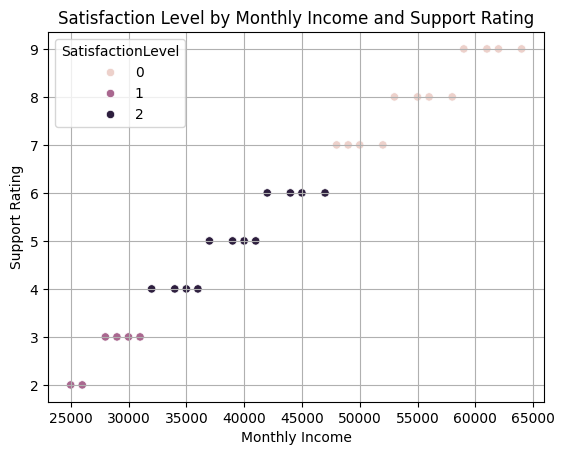

In [9]:
# Step No 7 : Visualization of Data 
sns.scatterplot(x = "MonthlyIncome" , y = "SupportRating" , hue = df["SatisfactionLevel"] , data = df)

# Set title and labels 
plt.title("Satisfaction Level by Monthly Income and Support Rating")

# Set x-axis 
plt.xlabel("Monthly Income")

# Set y-axis 
plt.ylabel("Support Rating")

# Enable grid 
plt.grid()

#Save the Plot 
plt.savefig("images/MontlyIncome_SupportRating_SatisfactionLevel(Ordinal Logistic Regression).png")

# Show the Plot 
plt.show()

In [10]:
# Step No 8 : 
# Split the dataset into training and testing sets 
X_train , X_test , y_train , y_test = train_test_split(
    X , 
    y , 
    test_size = 0.2 , 
    random_state = 42
)

In [11]:
# Step No 9 : Intialize Ordinal Logistic Regression Model

# Create Ordinal Logistic Regression model object 
model = LogisticAT()

In [12]:
# Step No 10 : Model Training 

# Train model 
model.fit(X_train , y_train)

LogisticAT()

In [13]:
# Step No 11 : Model Prediction 
# Predict satisfaction levels
y_pred = model.predict(X_test)

# Display predicated values 
print("Predicted Satisfaction Levels : ")
print(y_pred)

Predicted Satisfaction Levels : 
[0 2 0 2 1 0]


In [14]:
# Step No 12 : Model Evaluation 

# Calculate accuracy 
print("accuracy score : ")
print(accuracy_score(y_test , y_pred ))

# Calculate classification report 
print("Classification Report : ")
print(classification_report(y_test , y_pred))

# Calculate confusion matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred ))

accuracy score : 
0.3333333333333333
Classification Report : 
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2

    accuracy                           0.33         6
   macro avg       0.22      0.33      0.27         6
weighted avg       0.22      0.33      0.27         6

Confusion Matrix : 
[[2 0 0]
 [0 0 2]
 [1 1 0]]


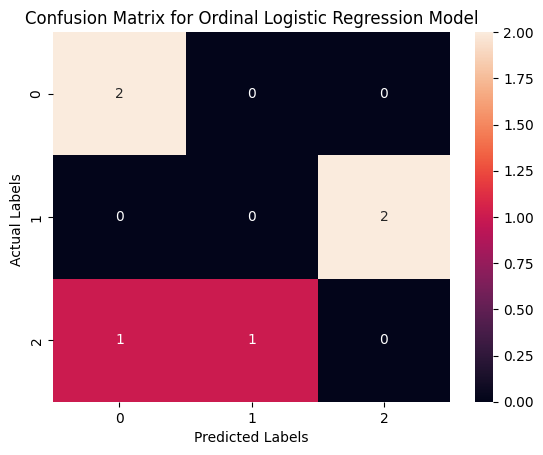

In [15]:
# Step No 13 : Visualization 

# Plot confusion matrix heatmap 
sns.heatmap(
    confusion_matrix(y_test , y_pred),
    annot = True,
    fmt = "d"
)

# Set title and Labels 
plt.title("Confusion Matrix for Ordinal Logistic Regression Model")

# Set x-axis label 
plt.xlabel("Predicted Labels")

# Set y-axis label 
plt.ylabel("Actual Labels ")

# Save the Plot
plt.savefig("images/Confusion_Matrix_Ordinal_Logistic_Regression.png")

# Show the Plot
plt.show()

In [16]:
# Step No 14 : User Input 

# Take age Input
age = int(input("Enter age : "))

# Take income input 
income = float(input("Enter the Income : "))

# Take purchase frequency input 
purchase_frequency = int(input("Enter Purchase Frequency : "))

# Take support rating input 
support_rating = int(input("Enter Support Rating : "))

In [17]:
# Step No 15 : Predictions on User Input 
user_data = pd.DataFrame({
    "Age": [age],
    "Income": [income],
    "PurchaseFrequency": [purchase_frequency],
    "SupportRating": [support_rating]
})

# Predict statisfaction level 
result = model.predict(user_data)

# convert numeric prediction back to label 
final_result = encoder.inverse_transform(result.astype(int))



In [18]:
# Step No 16 : Final Output 
# Display final prediction
print(f"Predicted Customer Satisfaction level is : {final_result}")

Predicted Customer Satisfaction level is : ['Medium']
